Since it's image classification, access to google drive is highly adviced. We won't need to download the large data file with every run. I've checked, 5 GB is a lot to download with every new runtime.

So our **step one** is to mount our google drive

In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Then install and import the libraries i believe might be needed for the general steps. More shall be added as needed during development.

In [22]:
!pip install -q kaggle tensorflow matplotlib seaborn scikit-learn opencv-python

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import cv2
from sklearn.model_selection import train_test_split
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.optimizers import Adam


# Step 2: Data Loading and Preprocessing

In [5]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [6]:
gdrive_path = '/content/drive/MyDrive/CassavaData'

!mkdir -p "{gdrive_path}"

Now we can skip the next cell on future runtimes since the data will be in our google drive

In [7]:
# Navigate into Google Drive
%cd "{gdrive_path}"

# Download competition files
!kaggle competitions download -c cassava-leaf-disease-classification

/content/drive/MyDrive/CassavaData
^C


Well, the provided code that let's us download the dataset doesn't work. There's a work around though. I'll copy the download link and directly download it to the drive.

In [8]:
!wget -O /content/drive/MyDrive/CassavaData/cassava.zip "https://storage.googleapis.com/kaggle-competitions-data/kaggle-v2/13836/1718836/bundle/archive.zip?GoogleAccessId=web-data@kaggle-161607.iam.gserviceaccount.com&Expires=1746358350&Signature=AURHdnziR8RqrYYRql7TbNUl4LmZhNW%2F6MZoqItY9rZsF2uDAxV6lAu4Lt9%2BsTS3nYkh18lWMnmx1MExvK9WAOrV9c52GH%2FvyzU6QSzvrqrSMUo72AHdvqi9jRHkNZzd3ZUCRSKHWmTwtTIMgQlD7KjCvlnTvPmUx4cETPgywduxs7UILHZpRAGf7pSkBwiKAnkfxsZmaEde9gOFbQNEsKrBSP%2FYfH48xTTpi%2Fuizc0GBdCLN1EL%2BKy6Z45qOXwdZLoPqsn2DdTLp1ueeBgTrRx8yQ1Z9G%2BOFJb9dSHjJrSQqEPU64ntHjHKTTAHL8XQhtW6vPpncgle8qOxcZ2p%2BQ%3D%3D&response-content-disposition=attachment%3B+filename%3Dcassava-leaf-disease-classification.zip"


--2025-05-01 11:34:44--  https://storage.googleapis.com/kaggle-competitions-data/kaggle-v2/13836/1718836/bundle/archive.zip?GoogleAccessId=web-data@kaggle-161607.iam.gserviceaccount.com&Expires=1746358350&Signature=AURHdnziR8RqrYYRql7TbNUl4LmZhNW%2F6MZoqItY9rZsF2uDAxV6lAu4Lt9%2BsTS3nYkh18lWMnmx1MExvK9WAOrV9c52GH%2FvyzU6QSzvrqrSMUo72AHdvqi9jRHkNZzd3ZUCRSKHWmTwtTIMgQlD7KjCvlnTvPmUx4cETPgywduxs7UILHZpRAGf7pSkBwiKAnkfxsZmaEde9gOFbQNEsKrBSP%2FYfH48xTTpi%2Fuizc0GBdCLN1EL%2BKy6Z45qOXwdZLoPqsn2DdTLp1ueeBgTrRx8yQ1Z9G%2BOFJb9dSHjJrSQqEPU64ntHjHKTTAHL8XQhtW6vPpncgle8qOxcZ2p%2BQ%3D%3D&response-content-disposition=attachment%3B+filename%3Dcassava-leaf-disease-classification.zip
Resolving storage.googleapis.com (storage.googleapis.com)... 74.125.195.207, 172.253.117.207, 142.250.99.207, ...
Connecting to storage.googleapis.com (storage.googleapis.com)|74.125.195.207|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 6185662420 (5.8G) [application/zip]
Saving to: ‘/content/driv

In [9]:
!unzip /content/drive/MyDrive/CassavaData/cassava.zip -d /content/drive/MyDrive/CassavaData/cassava

# remove the zip file after. It's too big to keep in storage.
os.remove('/content/drive/MyDrive/CassavaData/cassava.zip')

Streaming output truncated to the last 5000 lines.
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3954487465.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3954910918.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3955391972.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3955442838.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3955739563.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3955931830.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3955972139.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3956075690.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3956077728.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3956155774.jpg  
  inflating: /content/drive/MyDrive/CassavaData/cassava/train_images/3956271103.jpg  
  i

now below is the new folder and file directory.

In [10]:
base_dir = '/content/drive/MyDrive/CassavaData/cassava'

# Paths to images and CSV
train_csv = os.path.join(base_dir, 'train.csv')
image_dir = os.path.join(base_dir, 'train_images')

Moving, we'll check the class distribution in the csv

In [11]:
df = pd.read_csv(train_csv)
print(df.head())
print(df['label'].value_counts())

         image_id  label
0  1000015157.jpg      0
1  1000201771.jpg      3
2   100042118.jpg      1
3  1000723321.jpg      1
4  1000812911.jpg      3
label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64


Okay, that... kind of makes no sense... I'll label them.

In [12]:
label_map = {
    0: 'Cassava Bacterial Blight (CBB)',
    1: 'Cassava Brown Streak Disease (CBSD)',
    2: 'Cassava Green Mottle (CGM)',
    3: 'Cassava Mosaic Disease (CMD)',
    4: 'Healthy'
}

df['class'] = df['label'].map(label_map)

In [13]:
print(df.head())
print(df['label'].value_counts())

         image_id  label                                class
0  1000015157.jpg      0       Cassava Bacterial Blight (CBB)
1  1000201771.jpg      3         Cassava Mosaic Disease (CMD)
2   100042118.jpg      1  Cassava Brown Streak Disease (CBSD)
3  1000723321.jpg      1  Cassava Brown Streak Disease (CBSD)
4  1000812911.jpg      3         Cassava Mosaic Disease (CMD)
label
3    13158
4     2577
2     2386
1     2189
0     1087
Name: count, dtype: int64


And now i realize how depressingly unbalanced this dataset is.
Cassava Bacterial Blight (CBB) has only approximately 1000 samples, while  Cassava Mosaic Disease (CMD) has an excess of more than 10,000. I can't ignore that even if I wanted to.
Balancing this dataset isn't a requirement of this unit so I'll give it the bare minimum attention.

ChatGPT recommends Class weights as an easy fix, so that's what we'll be doing

In [14]:
from sklearn.utils.class_weight import compute_class_weight

# Get class weights based on the labels in the dataframe
class_weights = compute_class_weight(
    'balanced',
    classes=np.unique(df['label']),
    y=df['label']
)

# Create a dictionary to map class indices to class weights
class_weight_dict = {i: class_weights[i] for i in range(len(class_weights))}
print(class_weight_dict)


{0: np.float64(3.9368905243790246), 1: np.float64(1.954956601187757), 2: np.float64(1.7935456831517183), 3: np.float64(0.3252317981456148), 4: np.float64(1.6606131160263873)}


Model Training

In [15]:
# Define image size and batch size
# IMG_SIZE = 224 # I'm reducing the image size cause it's taking forever to process this.
IMG_SIZE = 64
BATCH_SIZE = 32

# Create an ImageDataGenerator for data augmentation and preprocessing
datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2  # Split data into training and validation sets
)

In [16]:
# Prepare training and validation data generators
train_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='image_id',
    y_col='class',  # Changed y_col to 'class'
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training'
)

validation_generator = datagen.flow_from_dataframe(
    dataframe=df,
    directory=image_dir,
    x_col='image_id',
    y_col='class',  # Changed y_col to 'class'
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation'
)

Found 17118 validated image filenames belonging to 5 classes.
Found 4279 validated image filenames belonging to 5 classes.


In [17]:

# Load pre-trained ResNet50 model (excluding the top classification layer)
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE, IMG_SIZE, 3))

# Freeze the base model layers
for layer in base_model.layers:
    layer.trainable = False

In [18]:
# Add new classification layers on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dropout(0.5)(x)  # Add dropout for regularization
predictions = Dense(5, activation='softmax')(x)

In [19]:
# Create the final model
model = Model(inputs=base_model.input, outputs=predictions)

# Compile the model
model.compile(optimizer=Adam(learning_rate=0.0001), loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model with class weights
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // BATCH_SIZE,
    epochs=1,  # Just changed to 1 epochs because 10 was taking forever
    validation_data=validation_generator,
    validation_steps=validation_generator.samples // BATCH_SIZE,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


534/534 ━━━━━━━━━━━━━━━━━━━━ 557s 1s/step - accuracy: 0.2020 - loss: 1.7225 - val_accuracy: 0.5750 - val_loss: 1.5194


In [20]:
# Evaluate the model on the validation data
val_loss, val_accuracy = model.evaluate(validation_generator, steps=validation_generator.samples // BATCH_SIZE)
print(f'Validation Loss: {val_loss}')
print(f'Validation Accuracy: {val_accuracy}')

# Predict the classes on the validation data
predictions = model.predict(validation_generator, verbose=1)

# Convert predicted probabilities to class labels (highest probability)
predicted_classes = np.argmax(predictions, axis=1)


133/133 ━━━━━━━━━━━━━━━━━━━━ 107s 798ms/step - accuracy: 0.5702 - loss: 1.5219
Validation Loss: 1.519831895828247
Validation Accuracy: 0.5782424807548523
134/134 ━━━━━━━━━━━━━━━━━━━━ 106s 772ms/step


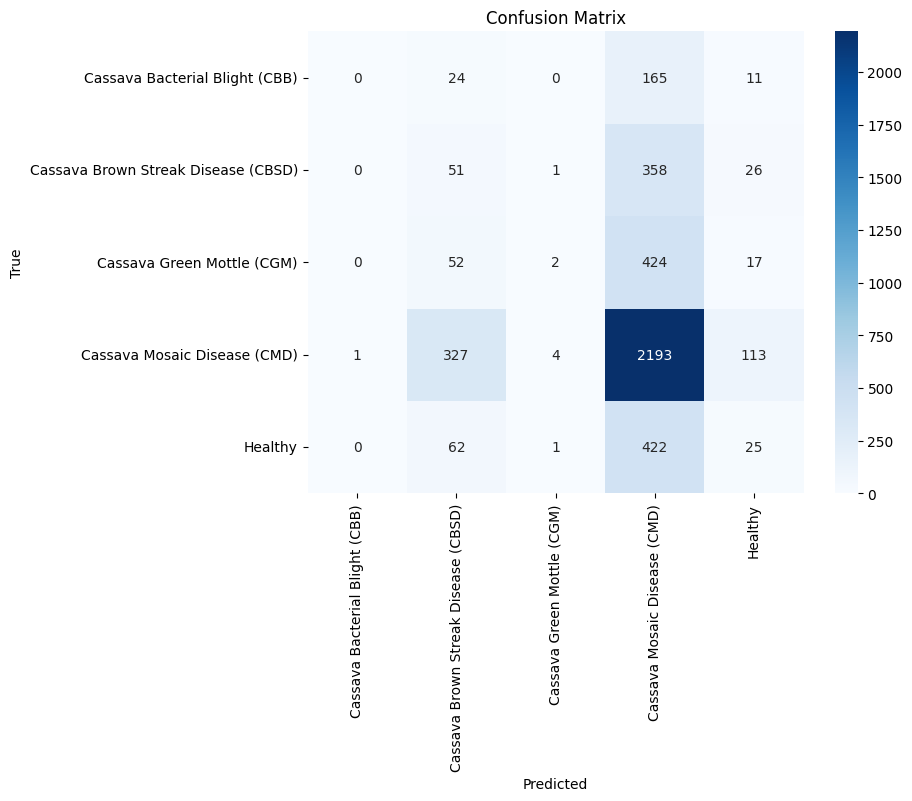


Classification Report:
                                     precision    recall  f1-score   support

     Cassava Bacterial Blight (CBB)       0.00      0.00      0.00       200
Cassava Brown Streak Disease (CBSD)       0.10      0.12      0.11       436
         Cassava Green Mottle (CGM)       0.25      0.00      0.01       495
       Cassava Mosaic Disease (CMD)       0.62      0.83      0.71      2638
                            Healthy       0.13      0.05      0.07       510

                           accuracy                           0.53      4279
                          macro avg       0.22      0.20      0.18      4279
                       weighted avg       0.43      0.53      0.46      4279



In [21]:
# Get the true labels from the validation set
true_classes = validation_generator.classes

# Generate the confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Display the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=validation_generator.class_indices.keys(), yticklabels=validation_generator.class_indices.keys())
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Print classification report
print("\nClassification Report:")
print(classification_report(true_classes, predicted_classes, target_names=validation_generator.class_indices.keys()))